In [1]:
import scipy.io as sio
import numpy as np
import sys
import os
import matplotlib.pyplot as plt

dir = os.getcwd()+"/data/"
data = sio.loadmat(dir+"nn_data.mat")
patterns = data['w']
phases = data['phase']

nsamps,ny,nx = np.shape(patterns)
perm = np.random.permutation(int(.9*nsamps))
training_samples = perm[:int(.8*nsamps)]
val_samples = perm[int(.8*nsamps):]
test_samples = np.arange(int(.9*nsamps), nsamps)

training_data = {'w': patterns[training_samples,:,:],
                 'theta': phases[training_samples,::4,::4]}
val_data = {'w': patterns[val_samples,:,:],
            'theta': phases[val_samples,::4,::4]}
test_data = {'w': patterns[test_samples,:,:],
            'theta': phases[test_samples,::4,::4]}

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, losses
from tensorflow.keras.models import Model

pat_train = training_data['w']
pat_test = test_data['w']
pat_val = val_data['w']
pat_train = pat_train.astype('float32')
pat_test = pat_test.astype('float32')
pat_val = pat_val.astype('float32')
print(pat_train.shape)
print(pat_test.shape)
print(pat_val.shape)

phase_train = training_data['theta']
phase_test = test_data['theta']
phase_val = val_data['theta']
phase_train = phase_train.astype('float32')
phase_test = phase_test.astype('float32')
phase_val = phase_val.astype('float32')
print(phase_train.shape)
print(phase_test.shape)
print(phase_val.shape)

2024-04-18 13:16:10.765215: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


(1200, 128, 128)
(150, 128, 128)
(150, 128, 128)
(1200, 32, 32)
(150, 32, 32)
(150, 32, 32)


In [3]:
_, dimy, dimx = phase_train.shape
class PhaseExtract(Model):
  def __init__(self, dimx, dimy):
    super(PhaseExtract, self).__init__()
    self.dimx = dimx
    self.dimy = dimy
    flatnum = int(dimx*dimy)
    self.phase = tf.keras.Sequential([
      layers.Flatten(),
      # layers.Dense(int(5*flatnum), activation='linear'),
      # layers.Dense(int(4*flatnum), activation='linear'),
      # layers.Dense(int(3*flatnum), activation='tanh'),
      # layers.Dense(int(2*flatnum), activation='linear'),
      # layers.Dense(flatnum, activation='tanh'),
      layers.Dense(512, activation='linear'),
      layers.Dense(512, activation='linear'),
      layers.Dense(512, activation='sigmoid'),
      layers.Dense(256, activation='linear'),
      layers.Dense(256, activation='linear'),
      layers.Dense(256, activation='sigmoid'),
      layers.Dense(256, activation='linear'),
      layers.Dense(256, activation='relu'),
      layers.Dense(512, activation='relu'),
      layers.Dense(flatnum, activation='linear'),
      layers.Reshape((dimy, dimx))
    ])

  def call(self, x):
    phase = self.phase(x)
    return phase

coarse_phase = PhaseExtract(dimx,dimy)


2024-04-18 13:16:22.200025: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [4]:
#coarse_phase.compile(optimizer='adam', loss=losses.MeanSquaredError())
coarse_phase.compile(optimizer=tf.keras.optimizers.Adam(1e-6),loss=losses.MeanSquaredError())
coarse_phase.fit(pat_train, phase_train,
                epochs=10000,
                batch_size=120,
                shuffle=True,
                validation_data=(pat_test, phase_test))

Epoch 1/10000
10/10 [==============================] - 2s 98ms/step - loss: 175.6234 - val_loss: 165.3224
Epoch 2/10000
10/10 [==============================] - 1s 62ms/step - loss: 175.6088 - val_loss: 165.3112
Epoch 3/10000
10/10 [==============================] - 1s 56ms/step - loss: 175.5941 - val_loss: 165.3002
Epoch 4/10000
10/10 [==============================] - 1s 57ms/step - loss: 175.5803 - val_loss: 165.2889
Epoch 5/10000
10/10 [==============================] - 1s 57ms/step - loss: 175.5656 - val_loss: 165.2778
Epoch 6/10000
10/10 [==============================] - 1s 59ms/step - loss: 175.5514 - val_loss: 165.2666
Epoch 7/10000
10/10 [==============================] - 1s 57ms/step - loss: 175.5369 - val_loss: 165.2552
Epoch 8/10000
10/10 [==============================] - 1s 58ms/step - loss: 175.5226 - val_loss: 165.2438
Epoch 9/10000
10/10 [==============================] - 1s 57ms/step - loss: 175.5078 - val_loss: 165.2324
Epoch 10/10000
10/10 [========================

In [5]:
coarse_phase.phase.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten (Flatten)           (None, 16384)             0         
                                                                 
 dense (Dense)               (None, 512)               8389120   
                                                                 
 dense_1 (Dense)             (None, 512)               262656    
                                                                 
 dense_2 (Dense)             (None, 512)               262656    
                                                                 
 dense_3 (Dense)             (None, 256)               131328    
                                                                 
 dense_4 (Dense)             (None, 256)               65792     
                                                                 
 dense_5 (Dense)             (None, 256)               6

In [6]:
unseen_phases = coarse_phase.phase(pat_val).numpy()

time step:  2
(32, 32)
time step:  113
(32, 32)
time step:  144
(32, 32)
time step:  113
(32, 32)
time step:  135
(32, 32)
time step:  143
(32, 32)
time step:  49
(32, 32)
time step:  42
(32, 32)
time step:  125
(32, 32)
time step:  114
(32, 32)


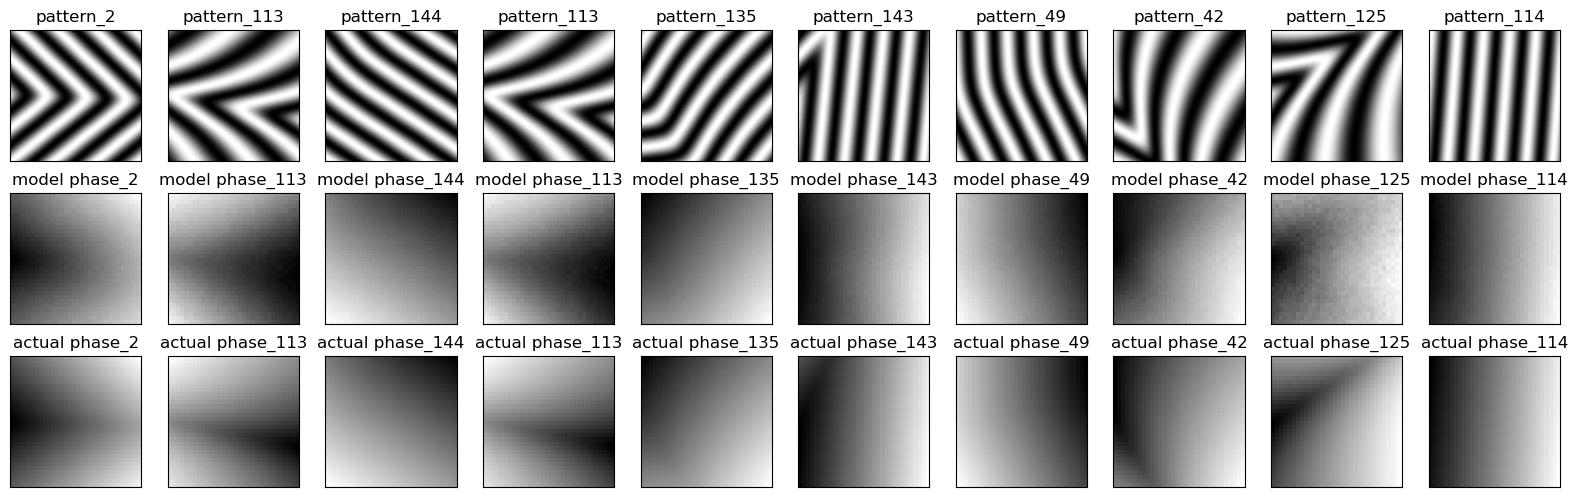

In [7]:
n = 10
plt.figure(figsize=(20, 6))
for i in range(n):
  idx = np.random.randint(1,149)
  print("time step: ",idx)
  # display original
  ax = plt.subplot(3, n, i + 1)
  plt.imshow(pat_val[idx])
  plt.title("pattern"+"_"+str(idx))
  plt.gray()
  ax.get_xaxis().set_visible(False)
  ax.get_yaxis().set_visible(False)

  # display reshaped encoded
  ax = plt.subplot(3, n, i + 1 + n)
  plt.imshow(unseen_phases[idx])
  plt.title("model phase"+"_"+str(idx))
  plt.gray()
  print(np.shape(unseen_phases[idx]))
  ax.get_xaxis().set_visible(False)
  ax.get_yaxis().set_visible(False)

  # display reconstruction
  ax = plt.subplot(3, n, i + 1 + 2*n)
  plt.imshow(phase_val[idx])
  plt.title("actual phase"+"_"+str(idx))
  plt.gray()
  ax.get_xaxis().set_visible(False)
  ax.get_yaxis().set_visible(False)

plt.savefig(os.getcwd() + "/figs/phase_extrat_nn_simple.png")